In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Optional
from scipy.integrate import solve_ivp
from tqdm import tqdm
from sklearn.linear_model import LinearRegression 
import os


In [ ]:
# DATASET GENERATION
def make_regression_2d(n_samples=40, noise_std=0.5, seed=42):
    """Generate a random 2D linear regression dataset."""
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2.0, 2.0, size=(n_samples, 2))
    # True relationship: y = 1.5*x1 - 0.8*x2 + 0.5
    w_true = np.array([1.5, -0.8])
    b_true = 0.5
    y = X @ w_true + b_true + rng.normal(0.0, noise_std, size=n_samples)
    return X, y

@dataclass(frozen=True)
class BatchSchedule:
    n_samples: int
    requested_batch_size: int
    effective_batch_size: int
    active_lanes: int
    n_blocks: int
    lane_lists: tuple[tuple[int, ...], ...]

def build_batch_schedule(n_samples: int, requested_batch_size: int) -> BatchSchedule:
    n_samples = max(1, int(n_samples))
    requested = max(1, min(int(requested_batch_size), n_samples))
    if n_samples % requested == 0:
        effective = requested
    else:
        effective = max(d for d in range(1, requested + 1) if n_samples % d == 0)
    lane_lists = tuple(tuple(range(lane, n_samples, effective)) for lane in range(effective))
    return BatchSchedule(n_samples, requested, effective, effective, n_samples // effective, lane_lists)

@dataclass(frozen=True)
class Reaction:
    reactants: Dict[str, int]
    products: Dict[str, int]
    k: float
    oscillator: Optional[int] = None

class MassActionCRN:
    def __init__(self, species: List[str], reactions: List[Reaction]):
        self.species = list(species)
        self.reactions = list(reactions)
        self.s_index = {s: i for i, s in enumerate(self.species)}
        self._compile()

    def _compile(self):
        m, r = len(self.species), len(self.reactions)
        self._delta = np.zeros((r, m), dtype=float)
        self._ks = np.zeros(r, dtype=float)
        self._oscillators = np.full(r, -1, dtype=int)
        self._react_idx, self._react_pow = [], []

        for j, rxn in enumerate(self.reactions):
            self._ks[j] = float(rxn.k)
            if rxn.oscillator is not None:
                self._oscillators[j] = int(rxn.oscillator)
            for sp, nu in rxn.reactants.items():
                self._delta[j, self.s_index[sp]] -= float(nu)
            for sp, nu in rxn.products.items():
                self._delta[j, self.s_index[sp]] += float(nu)
            
            idxs, pows = [], []
            for sp, nu in rxn.reactants.items():
                idxs.append(self.s_index[sp])
                pows.append(int(nu))
            self._react_idx.append(np.array(idxs, dtype=int))
            self._react_pow.append(np.array(pows, dtype=int))

    def rhs(self, y: np.ndarray, oscillator_vec: np.ndarray):
        r = len(self.reactions)
        v = np.zeros(r, dtype=float)
        for j in range(r):
            rate = self._ks[j]
            g = self._oscillators[j]
            if g >= 0:
                rate *= float(oscillator_vec[g])
            idxs, pows = self._react_idx[j], self._react_pow[j]
            if idxs.size == 0:
                v[j] = rate
            else:
                term = 1.0
                for ii, nu in zip(idxs, pows):
                    term *= y[ii] ** nu
                v[j] = rate * term
        return v @ self._delta, v

# HOPF CLOCK

@dataclass(frozen=True)
class HopfClockParams:
    n_clock: int
    mu: float
    omega: float
    kappa: float

def hopf_make_params(n_clock, phase_duration, mu=1.0, kappa=25.0):
    period = float(n_clock) * float(phase_duration)
    return HopfClockParams(n_clock=n_clock, mu=mu, omega=2*np.pi/period, kappa=kappa)

def hopf_phase(y: np.ndarray):
    th = np.arctan2(float(y[1]), float(y[0]))
    return th + 2*np.pi if th < 0 else th

def decode_clock_dualrail(y_clock_dr: np.ndarray):
    return np.array([float(y_clock_dr[0] - y_clock_dr[1]), float(y_clock_dr[2] - y_clock_dr[3])])

def init_clock_dualrail_phase0(params: HopfClockParams, eps=1e-9):
    r = float(np.sqrt(max(params.mu, 1e-12)))
    return np.array([r, eps, eps, eps], dtype=float)

def build_dualrail_hopf_clock_crn(params: HopfClockParams, k_ann: float = 80.0):
    from math import comb
    species = ['H_Xp', 'H_Xn', 'H_Zp', 'H_Zn']
    rxns = []
    dx_terms = [(params.mu, 1, 0), (-1.0, 3, 0), (-1.0, 1, 2), (-params.omega, 0, 1)]
    dz_terms = [(params.mu, 0, 1), (-1.0, 0, 3), (-1.0, 2, 1), (params.omega, 1, 0)]

    def add_signed_poly(target_pos, target_neg, terms):
        for base_coef, x_pow, z_pow in terms:
            for ix in range(x_pow + 1):
                cx = comb(x_pow, ix) * ((-1) ** (x_pow - ix))
                for iz in range(z_pow + 1):
                    cz = comb(z_pow, iz) * ((-1) ** (z_pow - iz))
                    coef = float(base_coef * cx * cz)
                    if abs(coef) < 1e-15: continue
                    reactants = {}
                    if ix > 0: reactants['H_Xp'] = int(ix)
                    if (x_pow - ix) > 0: reactants['H_Xn'] = int(x_pow - ix)
                    if iz > 0: reactants['H_Zp'] = int(iz)
                    if (z_pow - iz) > 0: reactants['H_Zn'] = int(z_pow - iz)
                    products = dict(reactants)
                    out = target_pos if coef > 0 else target_neg
                    products[out] = products.get(out, 0) + 1
                    rxns.append(Reaction(reactants, products, k=abs(coef)))

    add_signed_poly('H_Xp', 'H_Xn', dx_terms)
    add_signed_poly('H_Zp', 'H_Zn', dz_terms)
    rxns.append(Reaction({'H_Xp': 1, 'H_Xn': 1}, {}, k=float(k_ann)))
    rxns.append(Reaction({'H_Zp': 1, 'H_Zn': 1}, {}, k=float(k_ann)))
    return MassActionCRN(species, rxns)

In [ ]:
# CRN MODULES & LOGIC

def encode_dualrail(v: float): return max(v, 0.0), max(-v, 0.0)
def decode_dualrail(p: float, n: float): return float(p - n)

def add_decay_nonneg(rxns, OUT, k, osc):
    rxns.append(Reaction({OUT:1}, {}, k, osc))

def build_lr_crn_with_batch_loader(X_batch, y_batch, n_clock, cfg, schedule):
    n_samples, lanes = X_batch.shape[0], schedule.active_lanes
    lane_lists, block_scale = schedule.lane_lists, cfg.eta / schedule.effective_batch_size

    o_load, o_hand, o_shift = 0, 1, 2
    o_pred = 3  # Combined Forward Pass
    o_err  = 4  # Expanded Error
    o_grad = 5  # Cross-multiplication Gradient
    o_com  = 6  # Commit
    # o_rst  = 7  # Reset

    def L(base, lane): return f'{base}_l{lane}'
    rxns, species = [], ['W1p', 'W1n', 'W2p', 'W2n', 'Bp', 'Bn', 'R1p', 'R1n', 'R2p', 'R2n', 'Zp', 'Zn']
    
    sample_species = ['I1p', 'I1n', 'I2p', 'I2n', 'Yp', 'Yn']
    lane_active = ['X1p', 'X1n', 'X2p', 'X2n', 'L_Yp', 'L_Yn']
    lane_transient = ['Pp', 'Pn', 'Ep', 'En']

    for j in range(n_samples): species.extend([f'{nm}_{j}' for nm in sample_species])
    for lane, samples in enumerate(lane_lists):
        species.extend([L(nm, lane) for nm in lane_active + lane_transient])
        species.extend([f'C{j}_l{lane}' for j in samples] + [f'Ctil{j}_l{lane}' for j in samples])

    # Slots 0,1,2: Load and Shift
    for lane, samples in enumerate(lane_lists):
        for j in samples:
            pairs = [('I1p','X1p'), ('I1n','X1n'), ('I2p','X2p'), ('I2n','X2n'), ('Yp','L_Yp'), ('Yn','L_Yn')]
            for src, dst in pairs:
                rxns.append(Reaction({f'C{j}_l{lane}':1, f'{src}_{j}':1}, {f'C{j}_l{lane}':1, f'{src}_{j}':1, L(dst, lane):1}, cfg.k_load, o_load))
        for nm in lane_active: add_decay_nonneg(rxns, L(nm, lane), cfg.k_load, o_load)
        for pos, j in enumerate(samples):
            nxt = samples[(pos + 1) % len(samples)]
            rxns.append(Reaction({f'C{j}_l{lane}': 1}, {f'Ctil{j}_l{lane}': 1}, cfg.k_load, o_hand))
            rxns.append(Reaction({f'Ctil{j}_l{lane}': 1}, {f'C{nxt}_l{lane}': 1}, cfg.k_load, o_shift))

    for lane in range(lanes):
        # Slot 3: Combined Forward Pass (Pp, Pn)
        rxns.append(Reaction({'W1p':1, L('X1p', lane):1}, {'W1p':1, L('X1p', lane):1, L('Pp', lane):1}, cfg.k_ff, o_pred))
        rxns.append(Reaction({'W1n':1, L('X1n', lane):1}, {'W1n':1, L('X1n', lane):1, L('Pp', lane):1}, cfg.k_ff, o_pred))
        rxns.append(Reaction({'W2p':1, L('X2p', lane):1}, {'W2p':1, L('X2p', lane):1, L('Pp', lane):1}, cfg.k_ff, o_pred))
        rxns.append(Reaction({'W2n':1, L('X2n', lane):1}, {'W2n':1, L('X2n', lane):1, L('Pp', lane):1}, cfg.k_ff, o_pred))
        rxns.append(Reaction({'Bp':1}, {'Bp':1, L('Pp', lane):1}, cfg.k_ff, o_pred))

        rxns.append(Reaction({'W1p':1, L('X1n', lane):1}, {'W1p':1, L('X1n', lane):1, L('Pn', lane):1}, cfg.k_ff, o_pred))
        rxns.append(Reaction({'W1n':1, L('X1p', lane):1}, {'W1n':1, L('X1p', lane):1, L('Pn', lane):1}, cfg.k_ff, o_pred))
        rxns.append(Reaction({'W2p':1, L('X2n', lane):1}, {'W2p':1, L('X2n', lane):1, L('Pn', lane):1}, cfg.k_ff, o_pred))
        rxns.append(Reaction({'W2n':1, L('X2p', lane):1}, {'W2n':1, L('X2p', lane):1, L('Pn', lane):1}, cfg.k_ff, o_pred))
        rxns.append(Reaction({'Bn':1}, {'Bn':1, L('Pn', lane):1}, cfg.k_ff, o_pred))
        
        add_decay_nonneg(rxns, L('Pp', lane), cfg.k_ff, o_pred)
        add_decay_nonneg(rxns, L('Pn', lane), cfg.k_ff, o_pred)

        # Slot 4: Expanded Error (Ep = Yp + Pn, En = Yn + Pp)
        rxns.append(Reaction({L('L_Yp', lane):1}, {L('L_Yp', lane):1, L('Ep', lane):1}, cfg.k_ff, o_err))
        rxns.append(Reaction({L('Pn', lane):1}, {L('Pn', lane):1, L('Ep', lane):1}, cfg.k_ff, o_err))
        
        rxns.append(Reaction({L('L_Yn', lane):1}, {L('L_Yn', lane):1, L('En', lane):1}, cfg.k_ff, o_err))
        rxns.append(Reaction({L('Pp', lane):1}, {L('Pp', lane):1, L('En', lane):1}, cfg.k_ff, o_err))
        
        add_decay_nonneg(rxns, L('Ep', lane), cfg.k_ff, o_err)
        add_decay_nonneg(rxns, L('En', lane), cfg.k_ff, o_err)

        # Slot 5: Gradient Calculation W_new = W_old + eta * (Ep-En) * (Xp-Xn)
        # R = eta * (Ep-En) * (Xp-Xn)
        grad_rate = block_scale * cfg.k_upd
        
        # W1
        rxns.append(Reaction({L('Ep', lane):1, L('X1p', lane):1}, {L('Ep', lane):1, L('X1p', lane):1, 'R1p':1}, grad_rate, o_grad))
        rxns.append(Reaction({L('En', lane):1, L('X1n', lane):1}, {L('En', lane):1, L('X1n', lane):1, 'R1p':1}, grad_rate, o_grad))
        rxns.append(Reaction({L('Ep', lane):1, L('X1n', lane):1}, {L('Ep', lane):1, L('X1n', lane):1, 'R1n':1}, grad_rate, o_grad))
        rxns.append(Reaction({L('En', lane):1, L('X1p', lane):1}, {L('En', lane):1, L('X1p', lane):1, 'R1n':1}, grad_rate, o_grad))
        # W2
        rxns.append(Reaction({L('Ep', lane):1, L('X2p', lane):1}, {L('Ep', lane):1, L('X2p', lane):1, 'R2p':1}, grad_rate, o_grad))
        rxns.append(Reaction({L('En', lane):1, L('X2n', lane):1}, {L('En', lane):1, L('X2n', lane):1, 'R2p':1}, grad_rate, o_grad))
        rxns.append(Reaction({L('Ep', lane):1, L('X2n', lane):1}, {L('Ep', lane):1, L('X2n', lane):1, 'R2n':1}, grad_rate, o_grad))
        rxns.append(Reaction({L('En', lane):1, L('X2p', lane):1}, {L('En', lane):1, L('X2p', lane):1, 'R2n':1}, grad_rate, o_grad))
        # Bias
        rxns.append(Reaction({L('Ep', lane):1}, {L('Ep', lane):1, 'Zp': 1}, grad_rate, o_grad))
        rxns.append(Reaction({L('En', lane):1}, {L('En', lane):1, 'Zn': 1}, grad_rate, o_grad))

    # Slot 5 (Continued) Copy W into R globally
    for W, R in [('W1p', 'R1p'), ('W1n', 'R1n'), ('W2p', 'R2p'), ('W2n', 'R2n'), ('Bp', 'Zp'), ('Bn', 'Zn')]:
        rxns.append(Reaction({W: 1}, {W: 1, R: 1}, cfg.k_upd, o_grad))
        add_decay_nonneg(rxns, R, cfg.k_upd, o_grad)

    # Slot 6: Commit R back to W
    for R, W in [('R1p', 'W1p'), ('R1n', 'W1n'), ('R2p', 'W2p'), ('R2n', 'W2n'), ('Zp', 'Bp'), ('Zn', 'Bn')]:
        rxns.append(Reaction({R: 1}, {R: 1, W: 1}, cfg.k_commit, o_com))
        add_decay_nonneg(rxns, W, cfg.k_commit, o_com)

    # Slot 7: Reset transients
    # for nm in ['R1p', 'R1n', 'R2p', 'R2n', 'Zp', 'Zn']: add_decay_nonneg(rxns, nm, cfg.k_reset, o_rst)
    # for lane in range(lanes):
    #     for nm in lane_active + lane_transient:
    #         add_decay_nonneg(rxns, L(nm, lane), cfg.k_reset, o_rst)

    sp = list(dict.fromkeys(species))
    crn = MassActionCRN(sp, rxns)
    y0 = np.zeros(len(sp), dtype=float)
    idx = crn.s_index

    for lane, samples in enumerate(lane_lists): y0[idx[f'C{samples[0]}_l{lane}']] = 1.0
    for j in range(n_samples):
        y0[idx[f'I1p_{j}']], y0[idx[f'I1n_{j}']] = encode_dualrail(float(X_batch[j, 0]))
        y0[idx[f'I2p_{j}']], y0[idx[f'I2n_{j}']] = encode_dualrail(float(X_batch[j, 1]))
        y0[idx[f'Yp_{j}']], y0[idx[f'Yn_{j}']] = encode_dualrail(float(y_batch[j]))
        
    return crn, y0

# PYTHON BASELINE & CRN RUNNER
@dataclass
class Config:
    eta: float = 0.05
    k_ff: float = 24.0
    k_qsub: float = 24.0
    k_qann: float = 80.0
    k_upd: float = 24.0
    k_commit: float = 24.0
    k_load: float = 16.0
    k_reset: float = 24.0

def run_python_lr_baseline(X, y, epochs, batch_size, eta):
    n, d = X.shape
    schedule = build_batch_schedule(n, batch_size)
    w, b = np.zeros(d), 0.0
    W_hist, b_hist, mse_hist = [w.copy()], [b], []
    
    for _ in range(epochs):
        epoch_loss = 0.0
        for blk in range(schedule.n_blocks):
            lo, hi = blk * schedule.effective_batch_size, (blk + 1) * schedule.effective_batch_size
            grad_w, grad_b = np.zeros(d), 0.0
            for j in range(lo, hi):
                y_hat = w @ X[j] + b
                error = y[j] - y_hat
                epoch_loss += error**2
                grad_w += error * X[j]
                grad_b += error
            w += (eta / schedule.effective_batch_size) * grad_w
            b += (eta / schedule.effective_batch_size) * grad_b
        W_hist.append(w.copy())
        b_hist.append(b)
        mse_hist.append(epoch_loss / n)
    return np.vstack(W_hist), np.array(b_hist), np.array(mse_hist)

def run_crn_lr(X, y, epochs, batch_size, eta, phase_dur=1.2):
    n = len(X)
    schedule = build_batch_schedule(n, batch_size)
    cfg = Config(eta=eta)
    n_clock = 8 
    
    main_crn, y0_main = build_lr_crn_with_batch_loader(X, y, n_clock, cfg, schedule)
    clock_params = hopf_make_params(n_clock, phase_dur, kappa=300.0)
    clock_crn = build_dualrail_hopf_clock_crn(clock_params)
    y0_clock = init_clock_dualrail_phase0(clock_params)
    
    network = MassActionCRN(clock_crn.species + main_crn.species, clock_crn.reactions + main_crn.reactions)
    y0 = np.concatenate([y0_clock, y0_main])
    idx = network.s_index
    
    T_epoch = schedule.n_blocks * n_clock * phase_dur
    T_total = epochs * T_epoch
    t_eval = np.linspace(0, T_total, max(1000, epochs * 50))

    def _oscillator(y_vec):
        theta = hopf_phase(decode_clock_dualrail(y_vec[:4]))
        k = int(np.floor((theta / (2 * np.pi)) * n_clock)) % n_clock
        osc = np.zeros(n_clock)
        osc[k] = 1.0
        return osc

    print(f"Integrating coupled ODEs for {epochs} epochs (T={T_total:.1f})...")
    
    pbar = tqdm(total=T_total, desc="ODE Integration", 
                bar_format="{l_bar}{bar}| t={n:.1f}/{total_fmt} [{elapsed}<{remaining}]")
    
    state = {'last_t': 0.0}

    def rhs_wrapper(t, y_vec):
        if t > state['last_t']:
            pbar.update(t - state['last_t'])
            state['last_t'] = t
        return network.rhs(y_vec, _oscillator(y_vec))[0]

    sol = solve_ivp(rhs_wrapper, (0.0, T_total), y0, 
                    t_eval=t_eval, method='RK23', rtol=1e-3, atol=1e-6)

    pbar.close()

    Y, t_arr = sol.y, sol.t
    
    marker_times = np.linspace(0, T_total, epochs + 1)
    marker_idx = [np.argmin(np.abs(t_arr - tm)) for tm in marker_times]
    
    W_crn = np.zeros((epochs + 1, 2))
    b_crn = np.zeros(epochs + 1)
    
    for kk, ii in enumerate(marker_idx):
        ym = Y[:, ii]
        W_crn[kk, 0] = decode_dualrail(ym[idx['W1p']], ym[idx['W1n']])
        W_crn[kk, 1] = decode_dualrail(ym[idx['W2p']], ym[idx['W2n']])
        b_crn[kk] = decode_dualrail(ym[idx['Bp']], ym[idx['Bn']])

    mse_crn = []
    for kk in range(1, epochs + 1):
        w_tmp, b_tmp = W_crn[kk], b_crn[kk]
        preds = X @ w_tmp + b_tmp
        mse_crn.append(np.mean((y - preds)**2))
        
    return W_crn, b_crn, np.array(mse_crn)


# CONFIG
N_SAMPLES = 20
EPOCHS = 50
BATCH_SIZE = 10
ETA = 0.1 

X_raw, y_raw = make_regression_2d(N_SAMPLES, noise_std=0.2, seed=10)

# Ignore this (Earlier i was running on normalised data)
X_tr = X_raw
y_tr = y_raw

print("Running Scikit-Learn Baseline...")
sk_model = LinearRegression()
sk_model.fit(X_tr, y_tr)
W_sk = sk_model.coef_
b_sk = sk_model.intercept_
preds_sk = sk_model.predict(X_tr)
mse_sk = np.mean((y_tr - preds_sk)**2)

print("Running Python Baseline...")
W_py, b_py, mse_py = run_python_lr_baseline(X_tr, y_tr, EPOCHS, BATCH_SIZE, ETA)

print("Running CRN Simulation...")
W_crn, b_crn, mse_crn = run_crn_lr(X_tr, y_tr, EPOCHS, BATCH_SIZE, ETA)


Running Scikit-Learn Baseline...
Running Python Baseline...
Running CRN Simulation...
Integrating coupled ODEs for 50 epochs (T=960.0)...


ODE Integration: 100%|██████████| t=960.0/960.0 [01:33<00:00]


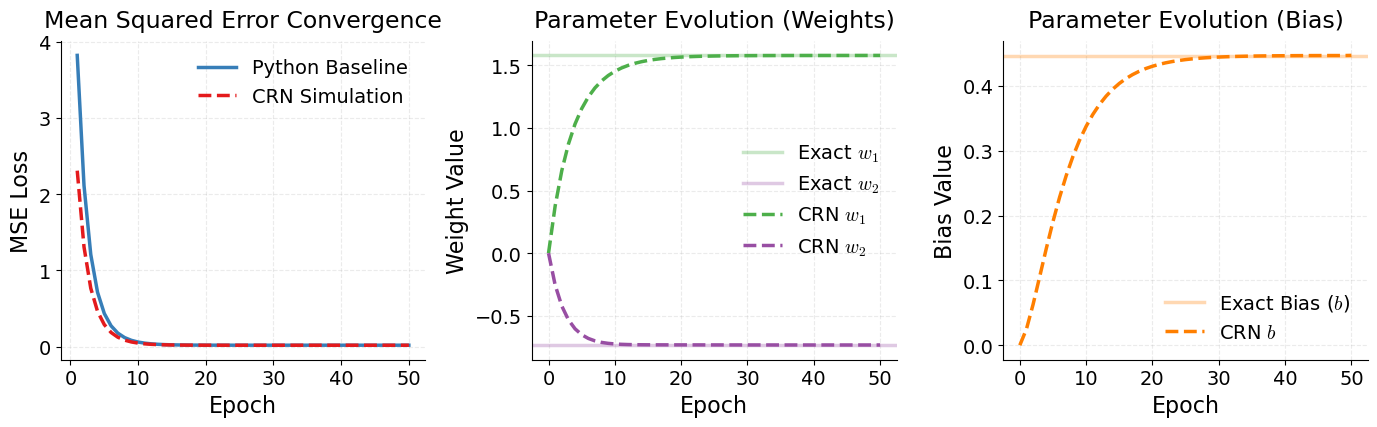

FINAL RESULTS SUMMARY:
Sklearn   - W: [ 1.57860543 -0.73459087], b: 0.4459, Final MSE: 0.0174
CRN       - W: [ 1.578125   -0.73291016], b: 0.4470, Final MSE: 0.0174


In [ ]:
# Paper Plot
# plt.rcParams.update({
#     "font.family": "sans-serif",
#     "font.sans-serif": ["DejaVu Sans", "Arial"],
#     "mathtext.fontset": "cm",
#     'font.size': 10,                
#     'axes.labelsize': 10,
#     'axes.titlesize': 11,
#     'legend.fontsize': 9,          
#     'xtick.labelsize': 9,
#     'ytick.labelsize': 9,
#     'lines.linewidth': 1.8        
# })
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial"],
    "mathtext.fontset": "cm",
    'font.size': 14,                
    'axes.labelsize': 16,
    'axes.titlesize': 17,
    'legend.fontsize': 14,          
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'lines.linewidth': 2.5        
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
ep_range = np.arange(1, EPOCHS + 1)
ep_all = np.arange(EPOCHS + 1)

axes[0].plot(ep_range, mse_py, linestyle='-', color='#377eb8', label='Python Baseline')
axes[0].plot(ep_range, mse_crn, linestyle='--', color='#e41a1c', label='CRN Simulation')

axes[0].set_title('Mean Squared Error Convergence', pad=10)#, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend(loc='upper right', frameon=False)


axes[1].axhline(W_sk[0], color='#4daf4a',  alpha=0.3, label=r'Exact $w_1$')
axes[1].axhline(W_sk[1], color='#984ea3',  alpha=0.3, label=r'Exact $w_2$')

axes[1].plot(ep_all, W_crn[:, 0], linestyle='--', color='#4daf4a', label=r'CRN $w_1$')
axes[1].plot(ep_all, W_crn[:, 1], linestyle='--', color='#984ea3', label=r'CRN $w_2$')

axes[1].set_title('Parameter Evolution (Weights)', pad=10)#, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weight Value')
axes[1].legend(loc='best', frameon=False)


axes[2].axhline(b_sk, color='#ff7f00',  alpha=0.3, label=r'Exact Bias ($b$)')

axes[2].plot(ep_all, b_crn, linestyle='--', color='#ff7f00', label=r'CRN $b$')

axes[2].set_title('Parameter Evolution (Bias)', pad=10)#, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Bias Value')
axes[2].legend(loc='best', frameon=False)


for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
os.makedirs("../plots", exist_ok=True)

plt.savefig(
    "../plots/multi_variate_plots.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
    dpi=600
)
plt.savefig(
    "../plots/multi_variate_plots.png",
    format="png",
    bbox_inches="tight",
    pad_inches=0.02,
    dpi=600
)

plt.show()

print("FINAL RESULTS SUMMARY:")
print(f"Sklearn   - W: {W_sk}, b: {b_sk:.4f}, Final MSE: {mse_sk:.4f}")
# print(f"Python    - W: {W_py[-1]}, b: {b_py[-1]:.4f}, Final MSE: {mse_py[-1]:.4f}")
print(f"CRN       - W: {W_crn[-1]}, b: {b_crn[-1]:.4f}, Final MSE: {mse_crn[-1]:.4f}")